# Hit Clustering

In [1]:
import h5py as h5
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import glob
plt.style.use('../../utils/dune.mplstyle')

import sys, os

# Path to repo root (two directories above notebook)
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(repo_root)

from utils.backtracking import get_charge_event_hits, hit_backtracker, get_ancestry # Now this works
from utils.my_ev_display import event_display

### Load Data (MC+Cosmic Overlap)

In [2]:
cosmic_data = '/global/cfs/cdirs/dune/www/data/2x2/nearline_run2/flowed_charge/ColdOperations/data/2025_Operations_Cold/source/AmBe_noSource_2/packet-0060105-2025_11_11_12_01_45_CST.FLOW.hdf5'
MC_data = '/global/cfs/cdirs/dune/users/lmlepin/2x2_neutron_prod/AmBe_tests/2x2_AmBe_in_mod2_prompt_window_test_11-19-2025_MOD.FLOW.hdf5'

In [3]:
# Notes on design of overlap_MC_Cosmic():
# Should achieve: Given arbitrarily many cosmic/MC files, overlap them on an event by event basis
# The output should be a list of overlapped event point clouds, with each point having a label for their interaction type (or is cosmic)

In [4]:
def overlap_MC_Cosmic(cosmic_file, MC_file):
    '''
    Overlap each MC event with a cosmic trigger
    
    If there are less cosmic triggers than MC events there will be a notice of how many events were successfully overlapped
    '''

    # Load cosmic data
    cosmic_hit_E = []
    cosmic_hit_location = []
    cosmic_hit_iogroup = []
    cosmic_hit_evtid = []

    for file in glob.iglob(cosmic_file):
        with h5.File(file, 'r') as f:
            # Filter out hits with negative energy (likley from noisy pixels) for now
            positive_hits = f['charge/calib_prompt_hits/data'][f['charge/calib_prompt_hits/data']['E']>0]
            cosmic_hit_E.extend(positive_hits['E'])
            cosmic_hit_location.extend(np.column_stack([np.array(positive_hits['ts_pps']), np.array(positive_hits['x']), np.array(positive_hits['y']), np.array(positive_hits['z'])]))
            cosmic_hit_iogroup.extend(positive_hits['io_group'])
            for i in range(len(positive_hits)):
                # Obtain the event id of each hit using the reference between calib_prompt_hits and charge/events
                ref_region_temp = f['charge/calib_prompt_hits/ref/charge/events/ref_region'][positive_hits['id'][i]]
                cosmic_hit_evtid.append(np.unique(f['charge/events/ref/charge/calib_prompt_hits/ref'][ref_region_temp[0]:ref_region_temp[1],0][f['charge/events/ref/charge/calib_prompt_hits/ref'][ref_region_temp[0]:ref_region_temp[1],1]==positive_hits['id'][i]])[0])

    cosmic_hit_E = np.array(cosmic_hit_E)
    cosmic_hit_location = np.array(cosmic_hit_location)
    cosmic_hit_iogroup = np.array(cosmic_hit_iogroup)
    cosmic_hit_evtid = np.array(cosmic_hit_evtid)

    # Load MC
    mc_hit_E = []
    mc_hit_location = []
    mc_hit_evtid = []
    mc_hit_n_process = []

    for file in glob.iglob(MC_file):
        with h5.File(file, 'r') as f:
            traj = f['mc_truth/trajectories/data']
            seg = f['mc_truth/segments/data']
            for event_id in np.unique(traj['event_id']):
                my_entry = event_id-1
                ev_traj= traj[traj['event_id']==event_id]
                ev_seg= seg[seg['event_id']==event_id]
                prompt_hits_backtrack, prompt_hits = get_charge_event_hits(my_entry,f)
                new_hits = hit_backtracker(prompt_hits_backtrack, prompt_hits, ev_seg, ev_traj)

                # Exclude negative hits
                positive_hits = new_hits[new_hits['E']>=0]
                mc_hit_E.extend(positive_hits['E'])
                mc_hit_location.extend(np.column_stack([positive_hits['ts_pps'], positive_hits['x'], positive_hits['y'], positive_hits['z']]))
                mc_hit_evtid.extend([event_id for i in range(len(positive_hits['E']))])
                mc_hit_n_process.extend(positive_hits['neutron_process'])

    mc_hit_E = np.array(mc_hit_E)
    mc_hit_location = np.array(mc_hit_location)
    mc_hit_evtid = np.array(mc_hit_evtid)
    mc_hit_n_process = np.array(mc_hit_n_process)

    # Combine the two dataset
    overlapped_E = []
    overlapped_location = []
    overlapped_evtid = []
    overlapped_n_process = []

    evtid_temp = np.unique(mc_hit_evtid)
    for i in range(min([len(np.unique(cosmic_hit_evtid)), len(np.unique(mc_hit_evtid))])):
        overlapped_E.extend(np.hstack([mc_hit_E[mc_hit_evtid==evtid_temp[i]], cosmic_hit_E[cosmic_hit_evtid==evtid_temp[i]]]))
        overlapped_location.extend(np.vstack([mc_hit_location[mc_hit_evtid==evtid_temp[i]], cosmic_hit_location[cosmic_hit_evtid==evtid_temp[i]]]))
        overlapped_evtid.extend(np.hstack([mc_hit_evtid[mc_hit_evtid==evtid_temp[i]], cosmic_hit_evtid[cosmic_hit_evtid==evtid_temp[i]]]))
        overlapped_n_process.extend(np.hstack([mc_hit_n_process[mc_hit_evtid==evtid_temp[i]], -1*np.ones(len(cosmic_hit_E[cosmic_hit_evtid==evtid_temp[i]]))]))

    return np.array(overlapped_E), np.array(overlapped_location), np.array(overlapped_evtid), np.array(overlapped_n_process)

In [5]:
E_overlapped, loc_overlapped, evtid_overlapped, n_process_overlapped = overlap_MC_Cosmic(cosmic_data, MC_data)

### Scan DBScan parameters optimize the clustering

In [6]:
# Array of DBScan test parameters

cluster_size_list = np.arange(3,11,1)
eps_list = np.arange(1,20,2)

print(cluster_size_list)
print(eps_list)

# Physical constants for analysis
# Drift velocity in :math:`cm/\mu s`

V_DRIFT = 0.1648 # cm / us
t_per_tick = 0.1 # us / tick

[ 3  4  5  6  7  8  9 10]
[ 1  3  5  7  9 11 13 15 17 19]


In [7]:
# Import packages for clustering

from sklearn.cluster import DBSCAN

In [8]:
def cluster_hits(locs, evt_ids, process_labels, cluster_size, Eps):
    '''
    Perform DBScan on hits from each event and evaluate performance
    '''

    hit_labels = []
    event_efficiency = []
    event_purity = []
    ncluster = []

    for index,i in enumerate([locs[evt_ids==j] for j in np.unique(evt_ids)]):
        if any(np.isnan(i[:,0]))==True or any(np.isnan(i[:,1]))==True or any(np.isnan(i[:,2]))==True or any(np.isnan(i[:,3]))==True:
                print('invalid hit location in event')
        else:
            # Convert the time dimension to drift distance using drift velocity
            i[:,0] *= V_DRIFT*t_per_tick
            # Apply DBScan
            capt_db = DBSCAN(eps=Eps, min_samples=cluster_size).fit(i)
            capt_cluster_label = capt_db.labels_
            hit_labels.append(capt_cluster_label)

            # Calculate the efficiency and purity event by event
            n_impure_hits = 0
            n_capt_hits = 0
            pure_capt_cluster_label = []
            for j in list(set(capt_cluster_label)):
                process_temp = process_labels[evt_ids==np.unique(evt_ids)[index]][np.where(capt_cluster_label==j)[0]]
                if all(k==1 for k in process_temp):
                    # Record clusters with only captures
                    pure_capt_cluster_label.append(j)
                    n_capt_hits += len(capt_cluster_label[capt_cluster_label==j])
                else:
                    # Record number of impure hits in clusters
                    n_impure_hits += len([k!=1 for k in process_temp])
                    n_capt_hits += len([k==1 for k in process_temp])

            #event_efficiency.append(len(capt_cluster_label[capt_cluster_label==-1])/len(capt_cluster_label))
            # New (correct) definition of efficiency
            event_efficiency.append(len(capt_cluster_label[capt_cluster_label!=-1])/n_capt_hits)
            event_purity.append(n_capt_hits/(n_capt_hits+n_impure_hits))
            ncluster.append(len(list(set(capt_cluster_label))))

    avg_eff = np.average(event_efficiency)
    avg_pur = np.average(event_purity)
    ncluster = np.average(ncluster)

    return avg_eff, avg_pur, ncluster

In [12]:
avg_eff_per_evt = []
avg_pur_per_evt = []
ncluster_per_evt = []

for m in cluster_size_list:
    for n in eps_list:
        eff,pur,nc = cluster_hits(loc_overlapped, evtid_overlapped, n_process_overlapped, m, n)
        avg_eff_per_evt.append(eff)
        avg_pur_per_evt.append(pur)
        ncluster_per_evt.append(nc)

invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hit location in event
invalid hi

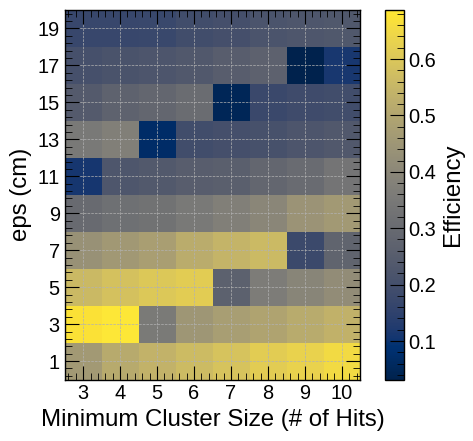

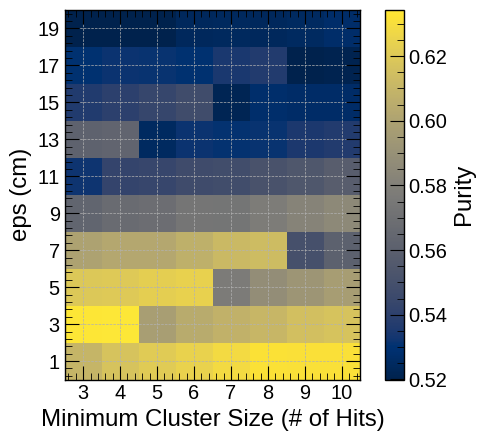

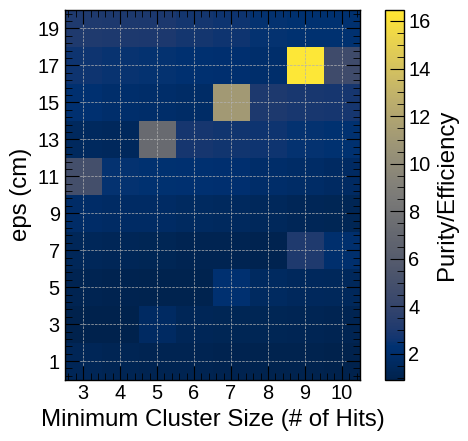

In [14]:
# Generate a 2d histogram of the efficiency and purity

# Turn the list of effciency and purity into 2d arrays
# eps varies across rows, cluster size vary across columns

eff_array = np.reshape(avg_eff_per_evt, (len(eps_list), len(cluster_size_list)))
pur_array = np.reshape(avg_pur_per_evt, (len(eps_list), len(cluster_size_list)))


# Efficiency
plt.imshow(eff_array, origin='lower')
plt.colorbar(label='Efficiency')
plt.ylabel('eps (cm)')
plt.xlabel('Minimum Cluster Size (# of Hits)')
plt.xticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.yticks(ticks=np.arange(0,len(eps_list),1), labels=eps_list)
#plt.title('Average Efficiency per Event')
plt.grid(True)
plt.show()

# Purity
plt.imshow(pur_array, origin='lower')
plt.colorbar(label='Purity')
plt.ylabel('eps (cm)')
plt.xlabel('Minimum Cluster Size (# of Hits)')
plt.xticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.yticks(ticks=np.arange(0,len(eps_list),1), labels=eps_list)
#plt.title('Average Purity per Event')
plt.grid(True)
plt.show()

# Purity/Efficiency
plt.imshow(pur_array/eff_array, origin='lower')
plt.colorbar(label='Purity/Efficiency')
plt.ylabel('eps (cm)')
plt.xlabel('Minimum Cluster Size (# of Hits)')
plt.xticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.yticks(ticks=np.arange(0,len(eps_list),1), labels=eps_list)
#plt.title('Purity/Efficiency per Event')
plt.grid(True)
plt.show()

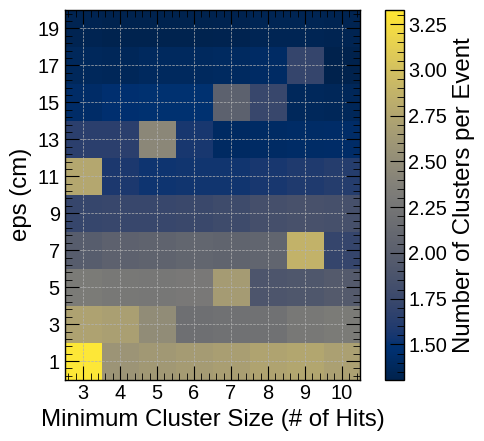

In [16]:
# Distribution of Number of Clusters per events

ncluster_array = np.reshape(ncluster_per_evt, (len(eps_list), len(cluster_size_list)))

plt.imshow(ncluster_array, origin='lower')
plt.colorbar(label='Number of Clusters per Event')
plt.ylabel('eps (cm)')
plt.xlabel('Minimum Cluster Size (# of Hits)')
plt.xticks(ticks=np.arange(0,len(cluster_size_list),1), labels=cluster_size_list)
plt.yticks(ticks=np.arange(0,len(eps_list),1), labels=eps_list)
#plt.title('Purity/Efficiency per Event')
plt.grid(True)
plt.show()